# Locking the search during generation updates

This notebook shows how Brush's locking mechanism works when you want to preserve part of a program while continuing evolution on new data.

The sequence below demonstrates three phases:

1. Fit an initial model on a base dataset.
2. Lock the upper part of the tree and continue with `partial_fit(...)`.
3. Unlock the model and run another `partial_fit(...)` to resume unrestricted search.

In [1]:
import numpy as np
import graphviz

from pybrush import BrushRegressor

## 1. Create a base problem and a shifted follow-up problem

The second dataset changes the coefficient pattern so that the model benefits from reuse, but still needs adaptation.

In [2]:
def mse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))

In [8]:
rng = np.random.default_rng(7)
n_samples = 500

X_base = rng.normal(size=(n_samples, 3))
y_base = np.array([
    4.0 * row[0] + 0.5 * row[1] if row[2] > 0 else -3.0 * row[1] + 0.2 * row[0]
    for row in X_base
])

# Shifts both in feature and target!
X_shifted = rng.normal(size=(n_samples, 3))
X_shifted[:, 0] = X_shifted[:, 0] * 1.4 + 1.0
X_shifted[:, 1] = X_shifted[:, 1] - 0.5

y_shifted = np.array([
    4.0 * row[0] - 0.25 * row[1] if row[2] > 0 else -5.0 * row[1] + 0.4 * row[0]
    for row in X_shifted
])

print('base shape:', X_base.shape, y_base.shape)
print('shifted shape:', X_shifted.shape, y_shifted.shape)
print('y base mean:   ', np.mean(y_base))
print('y shifted mean:', np.mean(y_shifted))

base shape: (500, 3) (500,)
shifted shape: (500, 3) (500,)
y base mean:    -0.07736613840644213
y shifted mean: 3.7191083728546763


## 2. Fit the initial generation window

This first fit builds a population on the base data. The compact tree structure is the part we will selectively preserve in the next step.

In [4]:
est = BrushRegressor(
    functions=['SplitOn', 'SplitBest', 'Mul', 'Add', 'Sub'],
    pop_size=500,
    max_gens=20,
    max_depth=5,
    max_size=10,
    start_from_decision_trees=True,
    constants_simplification=True,
    inexact_simplification=True,
    verbosity=1,
    random_state=7,
)

est.fit(X_base, y_base)

print('stage 1 base mse:', mse(y_base, est.predict(X_base)))
print('stage 1 shifted mse:', mse(y_shifted, est.predict(X_shifted)))
print('stage 1 model:')
print(est.best_estimator_.get_model())

Completed 100% [====================]
stage 1 base mse: 0.9389598521387683
stage 1 shifted mse: 12.693906935930773
stage 1 model:
If(x_0>=0.24,If(x_2>=-0.04,3.90,-3.03*x_1),If(x_2>=0.04,4.09*x_0,-2.98*x_1))


## 3. Lock the upper part of the tree

Locking the top levels keeps the learned structure fixed while lower nodes and weights can still adapt. This is the key step for controlled transfer between generation windows.

locked the top two levels of the current best estimator
locked model:
If(x_0>=0.24,If(x_2>=-0.04,3.90,-3.03*x_1),If(x_2>=0.04,4.09*x_0,-2.98*x_1))
locked tree:
If(x_0>=0.24)
|- If(x_2>=-0.04)
|  |- 3.90
|  |- -3.03*x_1
|- If(x_2>=0.04)
|  |- 4.09*x_0
|  |- -2.98*x_1


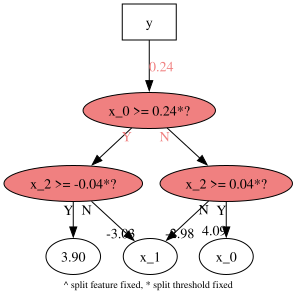

In [5]:
est.best_estimator_.program.lock_nodes(
    2,
    keep_leaves_unlocked=True,
    keep_current_weights=True,
)

print('locked the top two levels of the current best estimator')
print('locked model:')
print(est.best_estimator_.get_model())
print('locked tree:')
print(est.best_estimator_.get_model('tree'))
graphviz.Source(est.best_estimator_.get_model('dot'))

## 4. Continue evolution with the lock in place

`partial_fit(...)` reuses the current engine and population, then applies the requested lock depth before continuing the search on the new data.

Completed 100% [====================]
stage 2 base mse: 2.4325052852682343
stage 2 shifted mse: 0.9083711174803811
stage 2 model:
If(x_0>=0.24,If(x_2>=-0.04,4.06*x_0,-5.26*x_1),If(x_2>=0.04,3.96*x_0,-4.84*x_1))
stage 2 tree:
If(x_0>=0.24)
|- If(x_2>=-0.04)
|  |- 4.06*x_0
|  |- -5.26*x_1
|- If(x_2>=0.04)
|  |- 3.96*x_0
|  |- -4.84*x_1


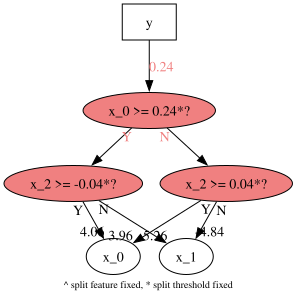

In [6]:
est.partial_fit(
    X_shifted,
    y_shifted,
    lock_nodes_depth=2,
    keep_leaves_unlocked=True,
    keep_current_weights=True,
)

print('stage 2 base mse:', mse(y_base, est.predict(X_base)))
print('stage 2 shifted mse:', mse(y_shifted, est.predict(X_shifted)))
print('stage 2 model:')
print(est.best_estimator_.get_model())
print('stage 2 tree:')
print(est.best_estimator_.get_model('tree'))
graphviz.Source(est.best_estimator_.get_model('dot'))

## 5. Stop locking and resume unrestricted search

Passing `end_depth=0` unlocks the tree again. The last call shows that generation updates can resume without preserving the prior lock state.

Completed 100% [====================]
stage 3 base mse: 5.744836281693709
stage 3 shifted mse: 3.5116005509724473
stage 3 unlocked model:
If(x_0>=2.05,If(x_2>=-0.12,3.98*x_0,0.40*Sub(x_0,12.50*x_1)),If(x_1>=-0.59,2.06*Sub(x_0,x_1),If(x_2>=0.00,4.17*x_0,-5.12*x_1)))
stage 3 unlocked tree:
If(x_0>=2.05)
|- If(x_2>=-0.12)
|  |- 3.98*x_0
|  |- 0.40*Sub
|  |  |- x_0
|  |  |- 12.50*x_1
|- If(x_1>=-0.59)
|  |- 2.06*Sub
|  |  |- x_0
|  |  |- x_1
|  |- If(x_2>=0.00)
|  |  |- 4.17*x_0
|  |  |- -5.12*x_1


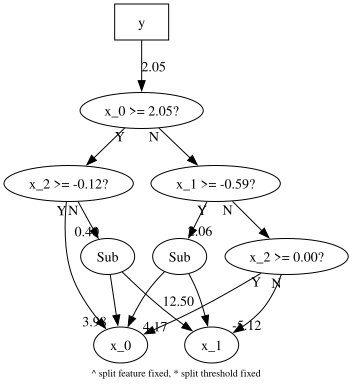

In [7]:
est.best_estimator_.program.lock_nodes(0, keep_leaves_unlocked=True, keep_current_weights=False)

est.max_gens = 50
est.partial_fit(
    X_shifted,
    y_shifted,
    lock_nodes_depth=0,
    keep_leaves_unlocked=True,
    keep_current_weights=False,
)

print('stage 3 base mse:', mse(y_base, est.predict(X_base)))
print('stage 3 shifted mse:', mse(y_shifted, est.predict(X_shifted)))
print('stage 3 unlocked model:')
print(est.best_estimator_.get_model())
print('stage 3 unlocked tree:')
print(est.best_estimator_.get_model('tree'))
graphviz.Source(est.best_estimator_.get_model('dot'))